# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as mticks
import matplotlib.dates as mdates
import glob
import statsmodels.tsa.api as tsa
plt.rcParams['figure.figsize'] = (12,4)
plt.rcParams['figure.facecolor'] = 'white'
sns.set_context("talk", font_scale=0.9)
SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns',50)



In [ ]:
df = pd.read_csv("C:/Users/Yousef/Desktop/Data_Science/Data/Chicago-Crime_All.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


In [ ]:
print(df.duplicated(subset='ID').sum())

0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')

In [ ]:
df.isna().sum()

ID                           0
Date                         0
Primary Type                 0
Description                  0
Location Description     10928
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Ward                    614846
Latitude                 88685
Longitude                88685
dtype: int64

In [ ]:
df = df.set_index('Date')
df = df.sort_index()
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7713109 entries, 2001-01-01 00:00:00 to 2022-12-31 23:55:00
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 603.2+ MB


## Comparing Police Districts

In [ ]:
df['Year'] = df.index.year
crime_2022 = df[df['Year'] == 2022]
crime_2022.head(3)

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year
Date,,,,,,,,,,,,
2022-01-01,12701677,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,2413,24.0,40.0,41.994004,-87.697387,2022
2022-01-01,12615410,DECEPTIVE PRACTICE,"THEFT BY LESSEE, MOTOR VEHICLE",STREET,False,False,1235,12.0,25.0,41.852750,-87.640816,2022
2022-01-01,12658052,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,511,5.0,8.0,41.717813,-87.598279,2022


In [ ]:
district_max = crime_2022['District'].value_counts().idxmax()
district_max_value = crime_2022['District'].value_counts().max()

In [ ]:
district_min = crime_2022['District'].value_counts().idxmin()
district_min_value = crime_2022['District'].value_counts().min()

In [ ]:
print(f"The district with the most crimes in 2022 is {district_max} with {district_max_value} crimes.")
print(f"The district with the least crimes in 2022 is {district_min} with {district_min_value} crimes.")

The district with the most crimes in 2022 is 8.0 with 14805 crimes.
The district with the least crimes in 2022 is 31.0 with 15 crimes.


## Crimes Across the Years

In [ ]:
crime_count = df['Year'].value_counts()
crime_count

Year
2002    486807
2001    485886
2003    475985
2004    469422
2005    453773
2006    448179
2007    437087
2008    427183
2009    392827
2010    370513
2011    351993
2012    336319
2013    307536
2014    275789
2016    269823
2017    269100
2018    268899
2015    264787
2019    261325
2022    238858
2020    212194
2021    208824
Name: count, dtype: int64

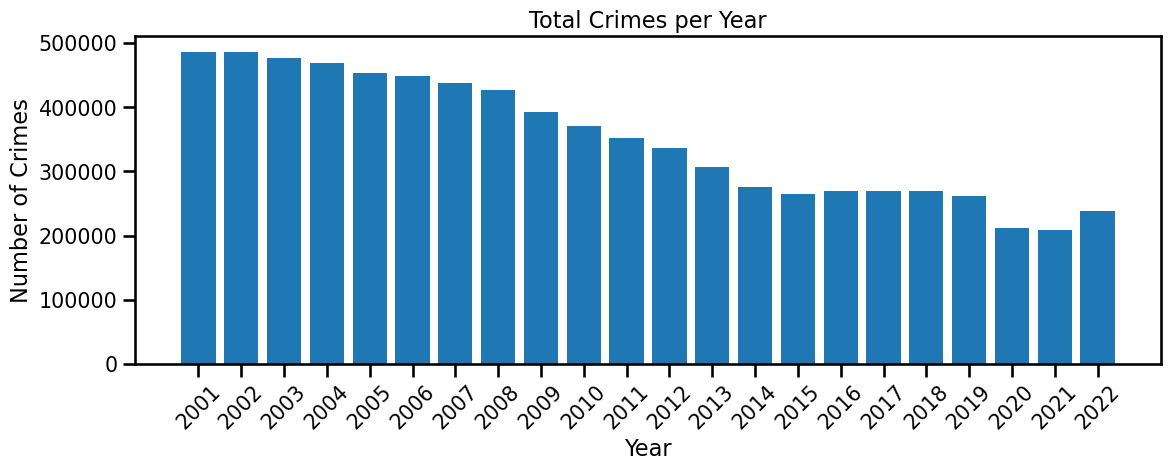

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(crime_count.index, crime_count.values)
ax.set_title('Total Crimes per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Crimes')
ax.set_xticks(crime_count.index)
ax.set_xticklabels(crime_count.index, rotation=45)
fig.tight_layout()

In [ ]:
if crime_count.diff().sum() > 0:
    overall_trend = "increasing"
else:
    overall_trend = "decreasing"

print(f"Crime in Chicago has been {overall_trend} over the years.")

Crime in Chicago has been decreasing over the years.


In [ ]:
crime_by_type = df.groupby(['Year', 'Primary Type']).size().unstack()

increasing_crimes = []
decreasing_crimes = []

for crime in crime_by_type.columns:
    trend = crime_by_type[crime].diff().sum()
    if trend > 0:
        increasing_crimes.append(crime)
    else:
        decreasing_crimes.append(crime)

In [ ]:
if overall_trend == "decreasing":
    print("\nCrimes going OPPOSITE to the overall trend (increasing while overall is decreasing):")
    for crime in increasing_crimes:
        print(f"  * {crime}")
else:
    print("\nCrimes going OPPOSITE to the overall trend (decreasing while overall is increasing):")
    for crime in decreasing_crimes:
        print(f"  * {crime}")


Crimes going OPPOSITE to the overall trend (increasing while overall is decreasing):
  * CONCEALED CARRY LICENSE VIOLATION
  * CRIMINAL SEXUAL ASSAULT
  * DECEPTIVE PRACTICE
  * HOMICIDE
  * HUMAN TRAFFICKING
  * NON - CRIMINAL
  * NON-CRIMINAL (SUBJECT SPECIFIED)
  * OBSCENITY
  * OTHER NARCOTIC VIOLATION
  * STALKING
  * WEAPONS VIOLATION


## Comparing AM vs. PM Rush Hour

In [ ]:
df['Hour'] = df.index.hour

am_rush = df[(df['Hour'] >= 7) & (df['Hour'] < 10)]
pm_rush = df[(df['Hour'] >= 16) & (df['Hour'] < 19)]

In [ ]:
print(f"AM Rush Hour crimes: {am_rush.shape[0]}")
print(f"PM Rush Hour crimes: {pm_rush.shape[0]}")

AM Rush Hour crimes: 770651
PM Rush Hour crimes: 1206353


In [ ]:
# Top 5 crimes each
print("\nTop 5 AM Rush Hour Crimes:")
print(am_rush['Primary Type'].value_counts(ascending=False).head())

print("\nTop 5 PM Rush Hour Crimes:")
print(pm_rush['Primary Type'].value_counts(ascending=False).head())


Top 5 AM Rush Hour Crimes:
Primary Type
THEFT              185239
BATTERY            108199
CRIMINAL DAMAGE     81281
BURGLARY            73999
OTHER OFFENSE       62453
Name: count, dtype: int64

Top 5 PM Rush Hour Crimes:
Primary Type
THEFT              293514
BATTERY            213002
CRIMINAL DAMAGE    134101
NARCOTICS          103032
ASSAULT             89600
Name: count, dtype: int64


In [ ]:
# Motor Vehicle Theft
am_mv = am_rush[am_rush['Primary Type'] == 'MOTOR VEHICLE THEFT'].shape[0]
pm_mv = pm_rush[pm_rush['Primary Type'] == 'MOTOR VEHICLE THEFT'].shape[0]

if am_mv > am_mv:
    print(f"Motor Vehicle Theft is more common during AM Rush Hour ({am_mv} vs {pm_mv})")
else:
    print(f"Motor Vehicle Theft is more common during PM Rush Hour ({pm_mv} vs {am_mv})")

Motor Vehicle Theft is more common during PM Rush Hour (53716 vs 41578)


## Comparing Months

In [ ]:
df['Month'] = df.index.month

month_count = df['Month'].value_counts()
month_count

Month
7     717232
8     710444
5     682932
6     681739
10    676285
9     668242
3     629704
4     627175
11    608961
1     601236
12    579768
2     529391
Name: count, dtype: int64

In [ ]:
most_crime_month = month_count.idxmax()
least_crime_month = month_count.idxmin()

In [ ]:
print(f"Month with most crimes: {most_crime_month}")
print(f"Month with least crimes: {least_crime_month}")

Month with most crimes: 7
Month with least crimes: 2


In [ ]:
monthly_by_type = df.groupby(['Month', 'Primary Type']).size().unstack()


opposite_crimes = []
for crime in monthly_by_type.columns:
    crime_peak = monthly_by_type[crime].idxmax()
    if crime_peak == least_crime_month:
        opposite_crimes.append(crime)


print("Crimes that peak in the lowest crime month:")
for crime in opposite_crimes:
    print(f"  * {crime}")

Crimes that peak in the lowest crime month:
  * NON-CRIMINAL (SUBJECT SPECIFIED)


## Comparing Holidays

In [ ]:
!pip install holidays

In [ ]:
import holidays
from holidays import country_holidays

us_holidays = country_holidays('US')
df["US Holiday"] = [us_holidays.get(day) for day in df.index]

In [ ]:
holiday_df = df[df['US Holiday'].notna()]
top3_holiday_crime = holiday_df.groupby('US Holiday').size().sort_values(ascending=False).head(3)
print(top3_holiday_crime)

US Holiday
New Year's Day      32725
Independence Day    22672
Labor Day           22164
dtype: int64


In [ ]:
for holiday in top3_holiday_crime.index:
    print(f"\nTop 5 crimes on {holiday}:")
    top5 = holiday_df[holiday_df['US Holiday'] == holiday]['Primary Type'].value_counts().head()
    print(top5)


Top 5 crimes on New Year's Day:
Primary Type
THEFT                         6845
BATTERY                       6043
CRIMINAL DAMAGE               3236
DECEPTIVE PRACTICE            2934
OFFENSE INVOLVING CHILDREN    2380
Name: count, dtype: int64

Top 5 crimes on Independence Day:
Primary Type
BATTERY            5805
THEFT              4074
CRIMINAL DAMAGE    3309
ASSAULT            1547
NARCOTICS          1522
Name: count, dtype: int64

Top 5 crimes on Labor Day:
Primary Type
BATTERY            4607
THEFT              4520
CRIMINAL DAMAGE    2475
NARCOTICS          2078
ASSAULT            1525
Name: count, dtype: int64


## Seasonality

In [ ]:
crimes_ts = df.groupby(['Date', 'Primary Type']).size().unstack(fill_value=0)

crimes_ts_month = crimes_ts.resample('M').sum()
total_crime_count = crimes_ts_month.sum(axis=1)

total_crime_count.head()

C:\Users\Yousef\AppData\Local\Temp\ipykernel_27680\4091082385.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  crimes_ts_month = crimes_ts.resample('M').sum()


Date
2001-01-31    38119
2001-02-28    33787
2001-03-31    40566
2001-04-30    40091
2001-05-31    41839
Freq: ME, dtype: int64

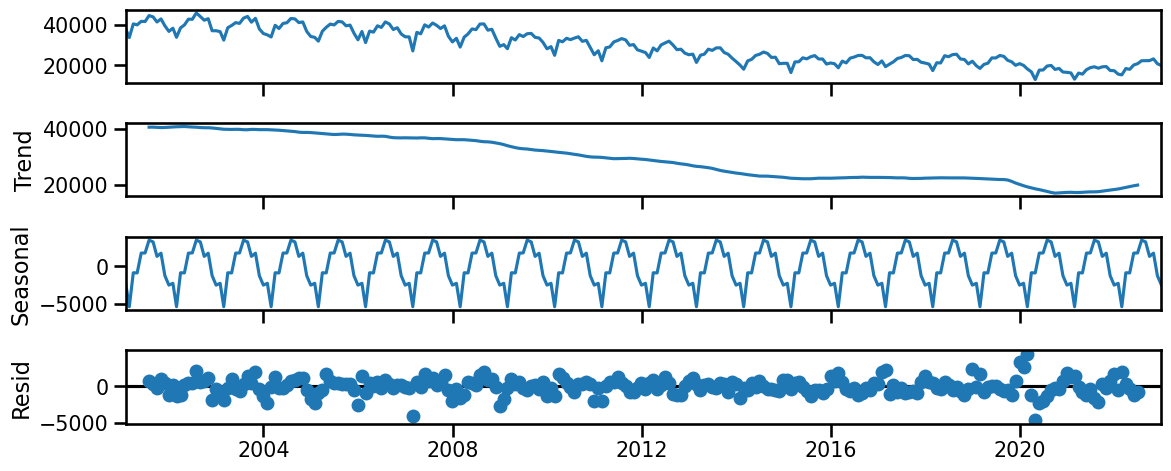

In [ ]:
decomp_crime = tsa.seasonal_decompose(total_crime_count, period=12)

fig = decomp_crime.plot()
fig.set_size_inches(12, 5)
fig.tight_layout()

In [ ]:
seasonal_zoomed = decomp_crime.seasonal['2017':'2020']

max_s = seasonal_zoomed.max()
min_s = seasonal_zoomed.min()
magnitude = max_s - min_s
max_ids = seasonal_zoomed.idxmax()
min_ids = seasonal_zoomed.idxmin()

In [ ]:
from scipy.signal import find_peaks

peaks, props = find_peaks(seasonal_zoomed, height=seasonal_zoomed.max())
peak_dates = seasonal_zoomed.index[peaks]
period = peak_dates[1] - peak_dates[0]

periods = []
for i in range(len(peak_dates)-1):
    delta = peak_dates[i+1] - peak_dates[i]
    periods.append(delta)

print("Calculated periods between peaks:", periods)

Calculated periods between peaks: [Timedelta('365 days 00:00:00'), Timedelta('365 days 00:00:00'), Timedelta('366 days 00:00:00')]


In [ ]:
def plot_seasonal(seasonal):
    minor_loc = mdates.MonthLocator()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(seasonal, zorder=3)
    ax.set(title='Seasonal Component for crimes')

    ax.xaxis.set_minor_locator(minor_loc)
    ax.grid(which='major', axis='x', lw=1, color='k', zorder=2)
    ax.grid(which='minor', axis='x', lw=0.5, color='lightgrey', zorder=1)
    fig.autofmt_xdate(rotation=90, ha='center')

    return fig, ax

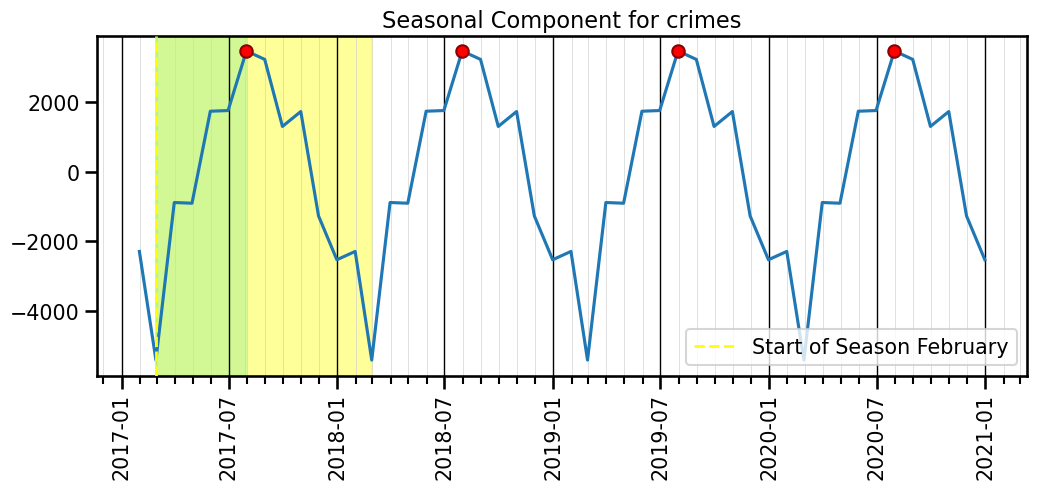

In [ ]:
fig, ax = plot_seasonal(seasonal_zoomed)
season_start = seasonal_zoomed.idxmin()

ax.axvspan(season_start, season_start + period, color='yellow', alpha=0.4, zorder=0)
ax.axvline(season_start, color='yellow', ls='--', lw=2,
           label=f"Start of Season {season_start.strftime('%B')}", zorder=4)
ax.scatter(peak_dates, props['peak_heights'], color='red', s=80, edgecolors='darkred', zorder=5)
ax.axvspan(seasonal_zoomed.idxmin(), seasonal_zoomed.idxmax(), color='lightgreen', alpha=0.4, zorder=0)

ax.legend(loc='lower right')

In [ ]:
print(f"1. How long is the cycle ? 365 days")
print(f"2. Maximum Seasonal Value: {max_s:.2f} , date: {max_ids.strftime('%Y-%m-%d')}")
print(f"3. Minimum Seasonal Value: {min_s:.2f} , date: {min_ids.strftime('%Y-%m-%d')}")
print(f"4. What is the magnitude of the cycle? {magnitude:.2f} crimes")

1. How long is the cycle ? 365 days
2. Maximum Seasonal Value: 3481.66 , date: 2017-07-31
3. Minimum Seasonal Value: -5416.09 , date: 2017-02-28
4. What is the magnitude of the cycle? 8897.74 crimes


# Time series ARIMA/SARIMA forecast Models

For this phase we will forecast **Assault** and **Battery** for the next 6 months

In [ ]:
import datetime as dt
import matplotlib.ticker as ticker
!pip install pmdarima -q
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs, nsdiffs
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
plt.rcParams['figure.figsize'] = (12, 3)

In [ ]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(15,8), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)
    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)
    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")
    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)
    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from sklearn.metrics import root_mean_squared_error

def regression_metrics_ts(ts_true, ts_pred, label=''):
    mae  = mean_absolute_error(ts_true, ts_pred)
    mse  = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r2   = r2_score(ts_true, ts_pred)
    mape = mean_absolute_percentage_error(ts_true, ts_pred) * 100
    print('-'*50, f'Metrics: {label}', '-'*50, sep='\n')
    print(f'MAE  = {mae:,.3f}')
    print(f'MSE  = {mse:,.3f}')
    print(f'RMSE = {rmse:,.3f}')
    print(f'R²   = {r2:,.3f}')
    print(f'MAPE = {mape:,.2f}%')
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs):

    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d, icbest) = tsa.adfuller(ts, **kwargs)

    # Converting output to a dictionary
    adfuller_results = {
        'Test Statistic': test_stat,
        '# of Lags Used': nlags,
        '# of Observations': nobs,
        'p-value': round(pval, 6),
        'alpha': alpha,
        'sig/stationary?': pval < alpha
    }

    return pd.DataFrame(adfuller_results, index=[label])


def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags



def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

     ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

#  Crime 1: Assault

In [ ]:
ts_assault = df[df['Primary Type'] == 'ASSAULT'].resample('M').size()
ts_assault.head()

C:\Users\Yousef\AppData\Local\Temp\ipykernel_27680\2752386868.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_assault = df[df['Primary Type'] == 'ASSAULT'].resample('M').size()


Date
2001-01-31    2123
2001-02-28    2029
2001-03-31    2824
2001-04-30    2746
2001-05-31    2903
Freq: ME, dtype: int64

### Check for null values

In [ ]:
print(' Missing values:', ts_assault.isna().sum())

 Missing values: 0


### Seasonal decomposition


Seasonal component: 684.89  (31.8% of total variation)


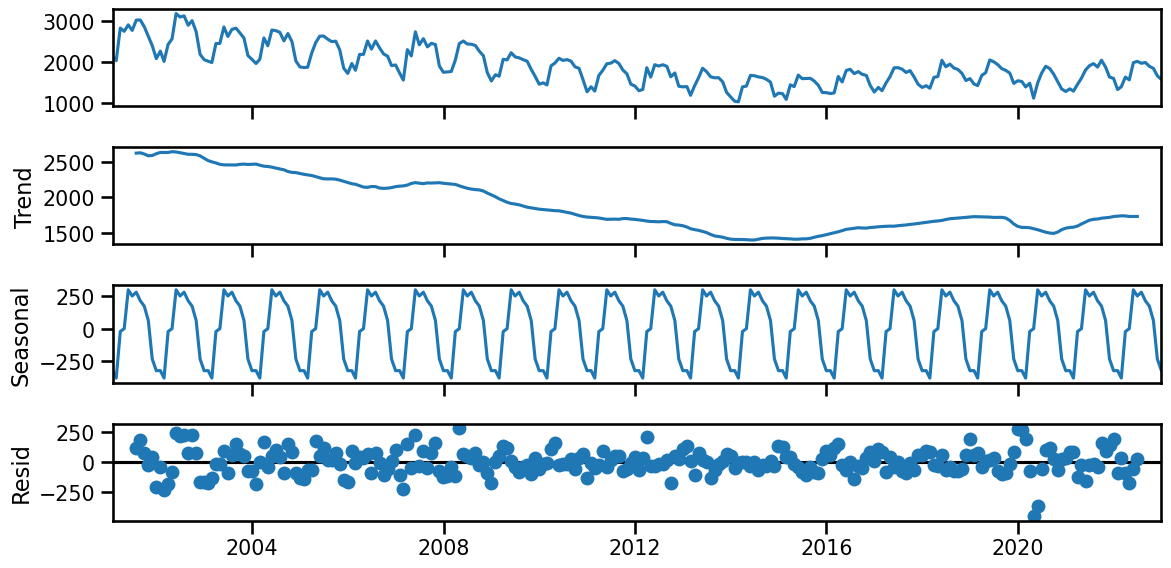

In [ ]:
decomp = tsa.seasonal_decompose(ts_assault, period=12)
fig = decomp.plot()
fig.set_size_inches(12, 6)
fig.tight_layout()

seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
ts_range = ts_assault.max() - ts_assault.min()
print(f'Seasonal component: {seasonal_delta:.2f}  'f'({seasonal_delta/ts_range*100:.1f}% of total variation)')

In [ ]:
get_adfuller_results(ts_assault, label='Assault Crime (raw)')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Assault Crime (raw),-1.836624,15,248,0.362437,0.05,False


In [ ]:
d = ndiffs(ts_assault)
D = nsdiffs(ts_assault, m=12)
print(f'd = {d}  (non-seasonal differencing needed)')
print(f'D = {D}  (seasonal differencing needed)')

d = 1  (non-seasonal differencing needed)
D = 0  (seasonal differencing needed)


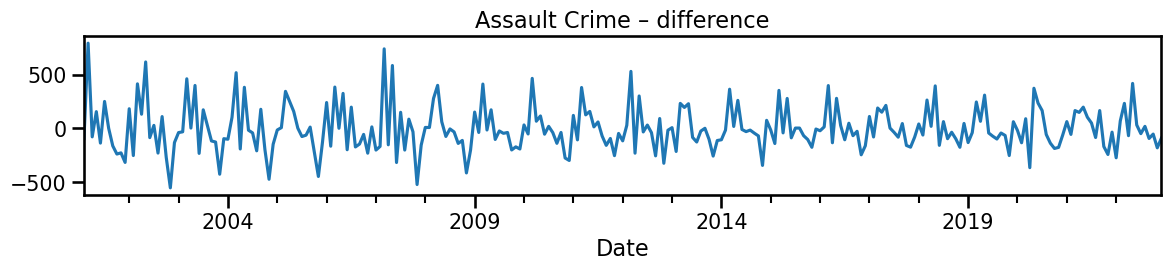

In [ ]:
ts_assault_diff = ts_assault.diff().dropna()
ts_assault_diff.plot(title='Assault Crime – difference')
plt.tight_layout()

In [ ]:
get_adfuller_results(ts_assault_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-3.936162,14,248,0.001784,0.05,True


### ACF / PACF

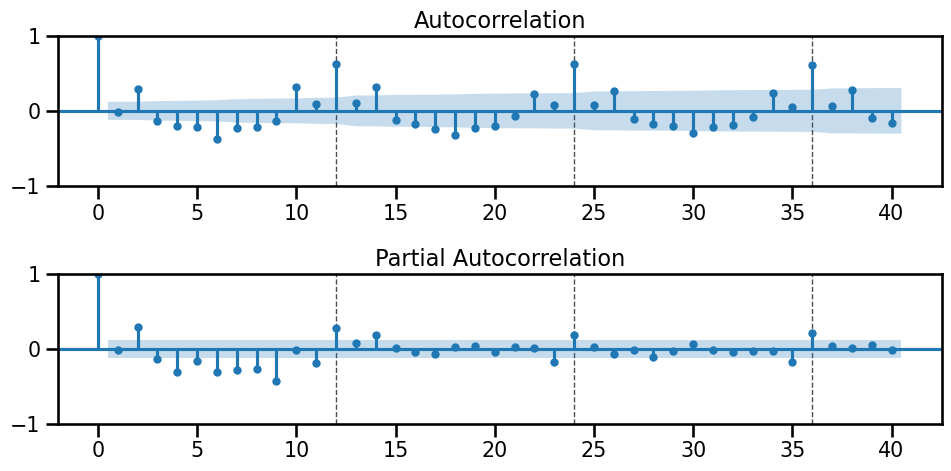

In [ ]:
plot_acf_pacf(ts_assault_diff, annotate_seas=True, m = 12);

### train / test split

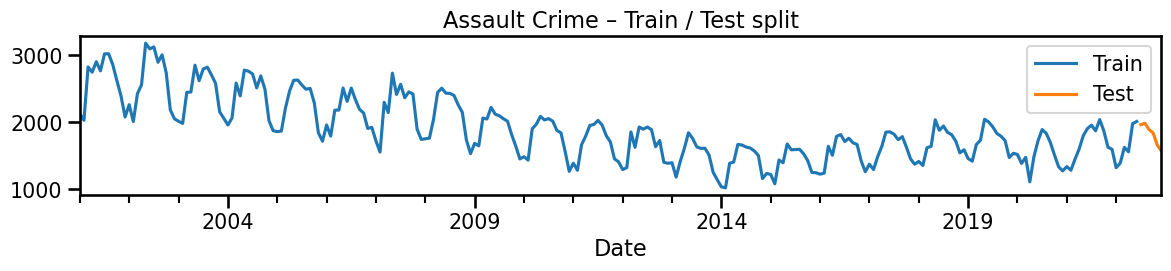

In [ ]:
train_assault, test_assault = train_test_split(ts_assault, test_size=6)
ax = train_assault.plot(label='Train')
test_assault.plot(ax=ax, label='Test')
ax.set_title('Assault Crime – Train / Test split')
ax.legend()
plt.tight_layout()

In [ ]:
p, d, q = 1, 1, 1
P, D, Q, m = 1, 0, 1, 12

sarima_assault = tsa.ARIMA(
    train_assault, order=(p, d, q), seasonal_order=(P, D, Q, m)
).fit()
sarima_assault.summary()

C:\Users\Yousef\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                                y   No. Observations:                  258
Model:             ARIMA(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -1612.066
Date:                          Mon, 29 Jun 2026   AIC                           3234.132
Time:                                  12:16:22   BIC                           3251.877
Sample:                              01-31-2001   HQIC                          3241.268
                                   - 06-30-2022                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9687      0.039     24.583      0.000       0.891       1.046
ma.L1         -0.9994      0.040    -25.080      0.000      -1.078      -0.921
ar.S.L12       0.9945      0.004    280.341      0.000       0.988       1.001
ma.S.L12      -0.8170      0.056    -14.666      0.000      -0.926      -0.708
sigma2      1.413e+04    859.403     16.439      0.000    1.24e+04    1.58e+04
===================================================================================
Ljung-Box (L1) (Q):                  22.41   Jarque-Bera (JB):                13.60
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.52   Skew:                             0.22
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

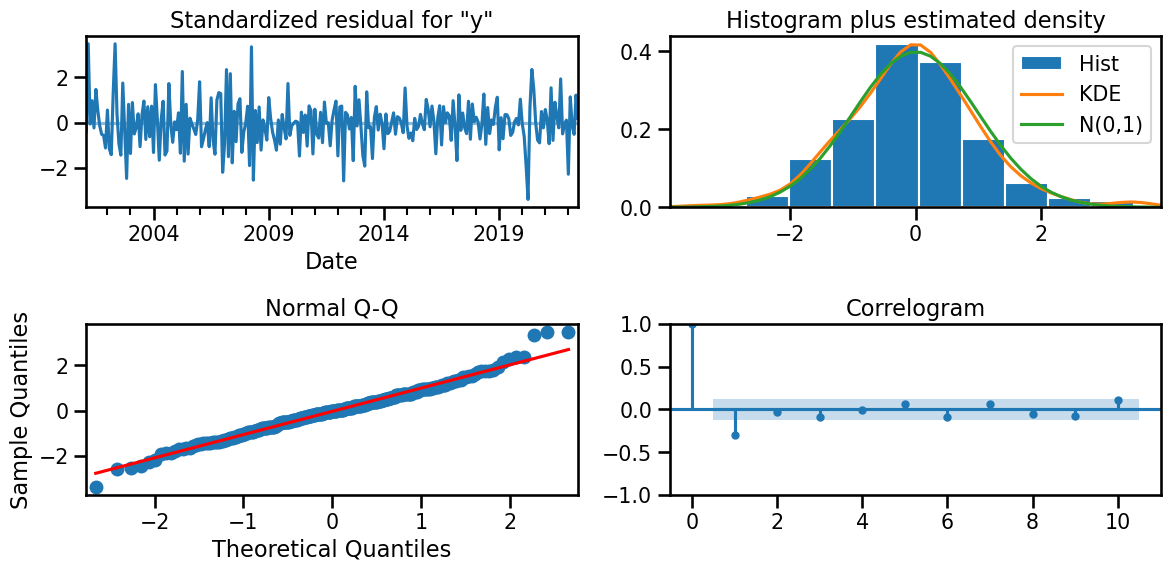

In [ ]:
fig = sarima_assault.plot_diagnostics()
fig.set_size_inches(12, 6)
fig.tight_layout()

--------------------------------------------------
Metrics: Manual SARIMA – Assault Crime
--------------------------------------------------
MAE  = 38.311
MSE  = 2,030.578
RMSE = 45.062
R²   = 0.914
MAPE = 2.11%


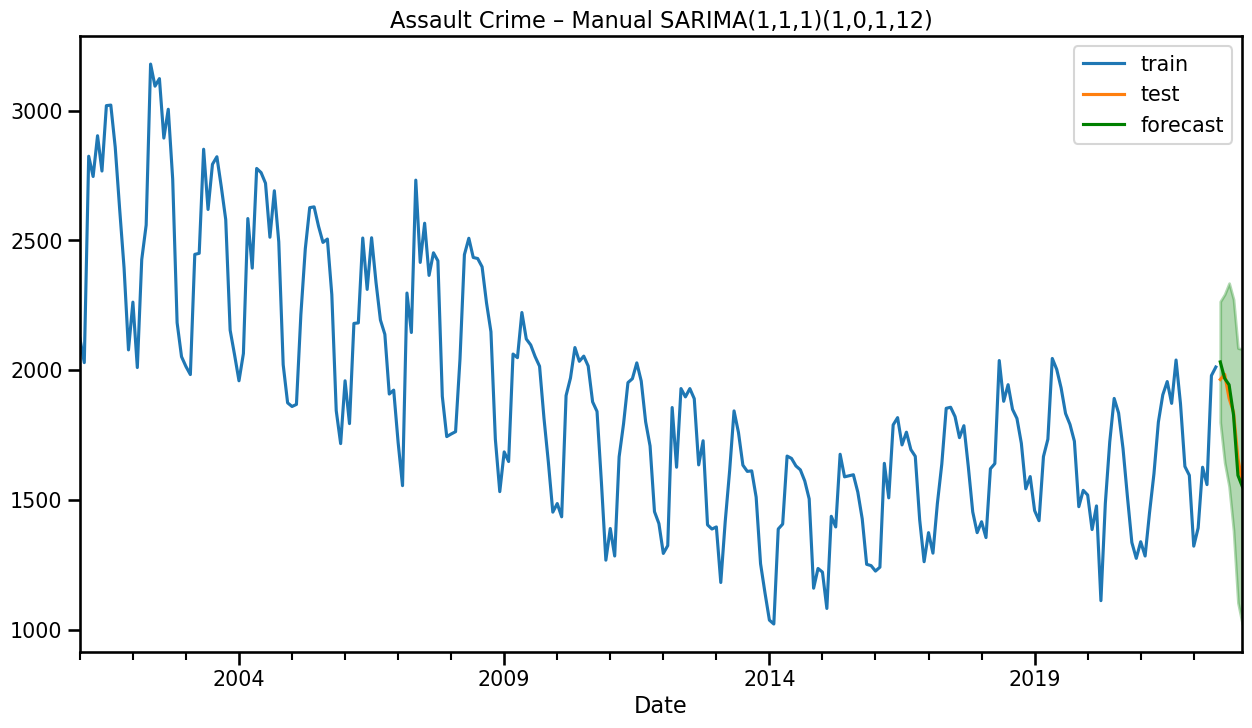

In [ ]:
forecast_manual_assault = sarima_assault.get_forecast(steps=len(test_assault)).summary_frame()
plot_forecast(train_assault, test_assault, forecast_manual_assault,title='Assault Crime – Manual SARIMA(1,1,1)(1,0,1,12)');
metrics_manual_assault = regression_metrics_ts(test_assault, forecast_manual_assault['mean'], label='Manual SARIMA – Assault Crime')

In [ ]:
auto_assault = pm.auto_arima(
    train_assault,
    seasonal=True, m=12,
    d=1, D=0,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    information_criterion='aic',
    trace=True, stepwise=True
)
print('Best order:', auto_assault.order)
print('Best seasonal order:', auto_assault.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=2.61 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3483.860, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3318.021, Time=0.51 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3405.065, Time=0.36 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3481.861, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=3485.758, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=1.33 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.13 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3404.125, Time=0.37 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=2.90 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=3337.645, Time=0.22 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=3313.233, Time=0.65 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=3462.085, Time=0.33 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=1.52 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=3

C:\Users\Yousef\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--------------------------------------------------
Metrics: auto_arima – Assault Crime
--------------------------------------------------
MAE  = 36.194
MSE  = 1,989.222
RMSE = 44.601
R²   = 0.916
MAPE = 2.03%


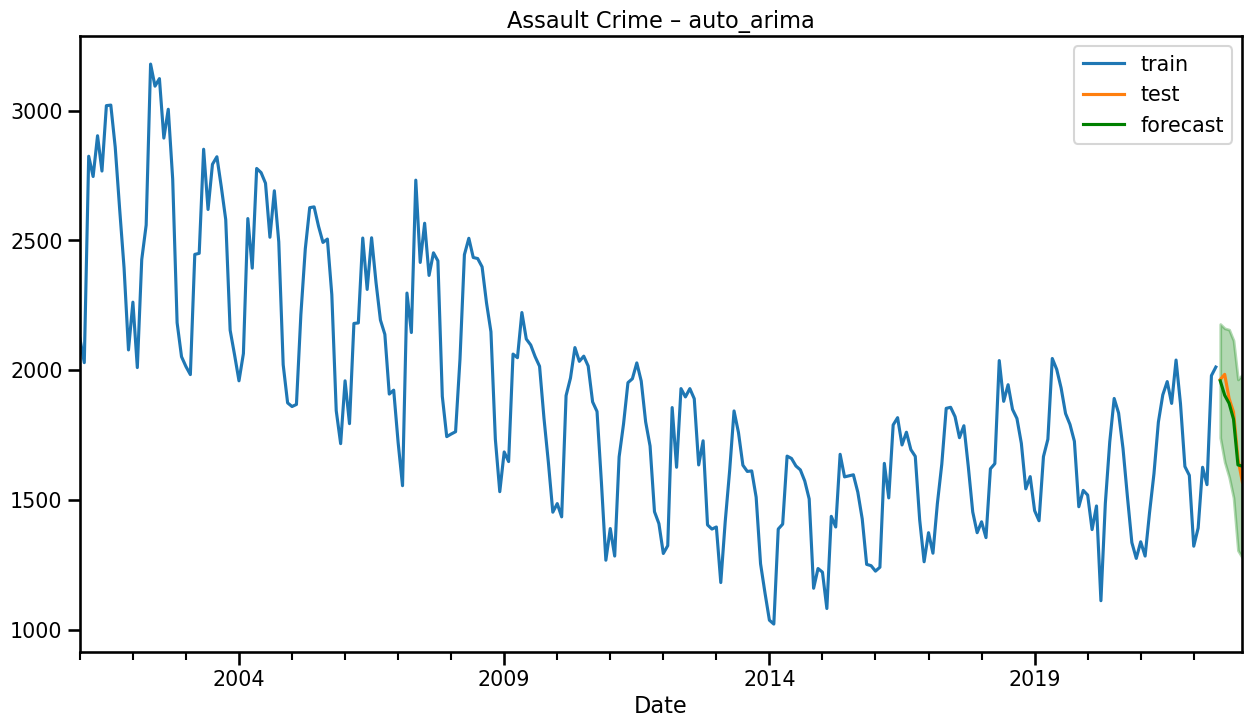

In [ ]:
# Fit statsmodels ARIMA with auto_arima
auto_model_assault = tsa.ARIMA(
    train_assault,
    order=auto_assault.order,
    seasonal_order=auto_assault.seasonal_order
).fit()

forecast_auto_assault = auto_model_assault.get_forecast(steps=len(test_assault)).summary_frame()
plot_forecast(train_assault, test_assault, forecast_auto_assault,title='Assault Crime – auto_arima');
metrics_auto_assault = regression_metrics_ts(test_assault, forecast_auto_assault['mean'], label='auto_arima – Assault Crime')

In [ ]:
print(metrics_manual_assault)
print(metrics_auto_assault)

{'MAE': 38.31108692426926, 'MSE': 2030.578385003297, 'RMSE': 45.06193942789521, 'R2': 0.9141545648353352, 'MAPE': 2.111616657190418}
{'MAE': 36.194359293528315, 'MSE': 1989.2215345068323, 'RMSE': 44.60068984339628, 'R2': 0.9159029813722832, 'MAPE': 2.026286709622213}


Manual SARIMA selected (lower MAPE) + other metrics

In [ ]:
final_assault = tsa.ARIMA(
    ts_assault,
    order=(3, 1, 0),
    seasonal_order=(2, 0, 2, 12)
).fit()

future_assault = final_assault.get_forecast(steps=6).summary_frame()
print('Forecast dates:')
print(future_assault[['mean', 'mean_ci_lower', 'mean_ci_upper']].round(0))

C:\Users\Yousef\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Forecast dates:
y             mean  mean_ci_lower  mean_ci_upper
2023-01-31  1538.0         1319.0         1756.0
2023-02-28  1503.0         1249.0         1757.0
2023-03-31  1701.0         1423.0         1980.0
2023-04-30  1663.0         1367.0         1960.0
2023-05-31  1960.0         1638.0         2282.0
2023-06-30  2007.0         1663.0         2352.0


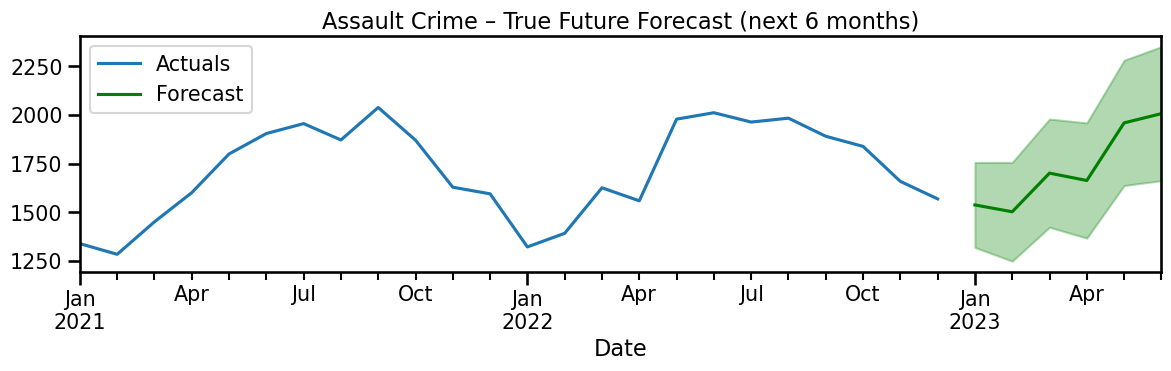

In [ ]:
# Plot: last 24 months of actuals + 6-month future forecast
fig, ax = plt.subplots(figsize=(12, 4))
ts_assault.iloc[-24:].plot(ax=ax, label='Actuals')
future_assault['mean'].plot(ax=ax, color='green', label='Forecast')
ax.fill_between(future_assault.index,
                future_assault['mean_ci_lower'],
                future_assault['mean_ci_upper'],
                color='green', alpha=0.3)
ax.set_title('Assault Crime – True Future Forecast (next 6 months)')
ax.legend()
fig.tight_layout()

In [ ]:
start_assault = future_assault['mean'].iloc[0]
end_assault   = future_assault['mean'].iloc[-1]
delta_assault = end_assault - start_assault
pct_assault   = (delta_assault / start_assault) * 100

print(f'Forecast start: {start_assault:,.0f} ')
print(f'Forecast end: {end_assault:,.0f} ')
print(f'Net change: {delta_assault:+,.0f}')
print(f'Percent change: {pct_assault:+.2f}%')

Forecast start: 1,538 
Forecast end: 2,007 
Net change: +470
Percent change: +30.53%


#  Crime 2: BATTERY

In [ ]:
ts_battery = df[df['Primary Type'] == 'BATTERY'].resample('M').size()
ts_battery.head()

C:\Users\Yousef\AppData\Local\Temp\ipykernel_27680\3325558601.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_battery = df[df['Primary Type'] == 'BATTERY'].resample('M').size()


Date
2001-01-31    6527
2001-02-28    6042
2001-03-31    7662
2001-04-30    8328
2001-05-31    8887
Freq: ME, dtype: int64

In [ ]:
print('Missing values:', ts_battery.isna().sum())

Missing values: 0


Seasonal component: 2040.13  (27.7% of total variation)


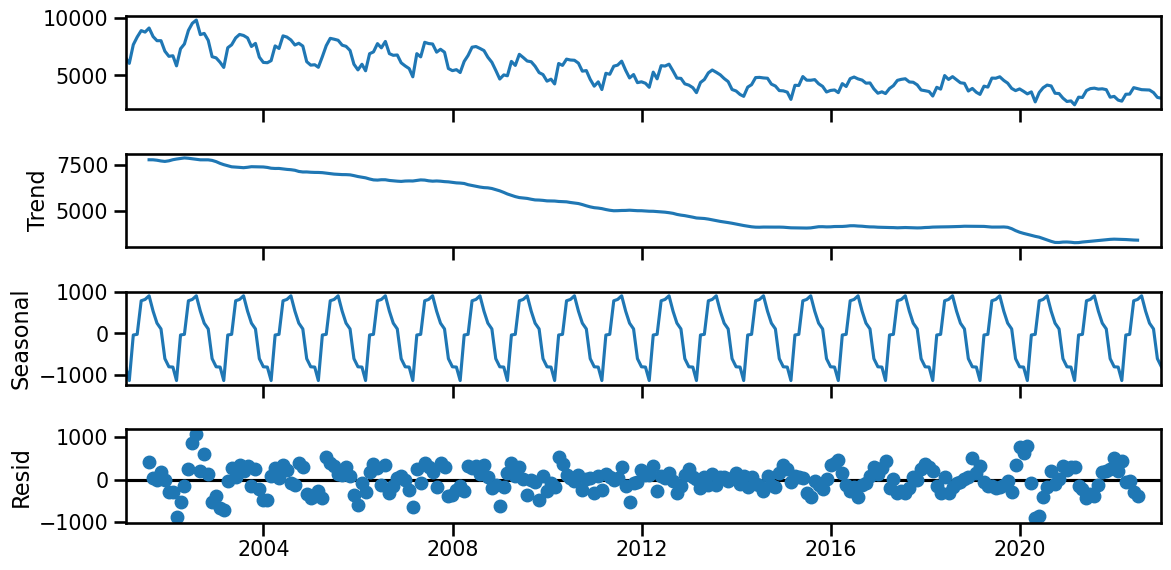

In [ ]:
decomp = tsa.seasonal_decompose(ts_battery, period=12)
fig = decomp.plot()
fig.set_size_inches(12, 6)
fig.tight_layout()

seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
ts_range = ts_battery.max() - ts_battery.min()
print(f'Seasonal component: {seasonal_delta:.2f}  'f'({seasonal_delta/ts_range*100:.1f}% of total variation)')

## Stationarity check

In [ ]:
get_adfuller_results(ts_battery, label='Battery')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Battery,-1.036843,15,248,0.739591,0.05,False


In [ ]:
d = ndiffs(ts_battery)
D = nsdiffs(ts_battery, m=12)
print(f'd = {d}')
print(f'D = {D}')

d = 1
D = 0


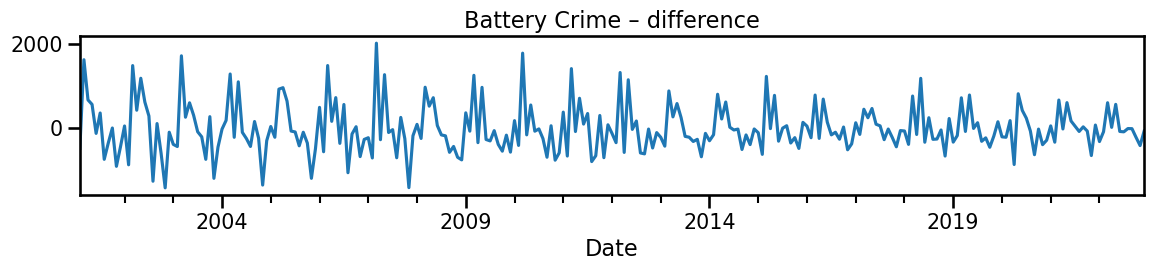

In [ ]:
ts_battery_diff = ts_battery.diff().dropna()
ts_battery_diff.plot(title='Battery Crime – difference')
plt.tight_layout()

In [ ]:
get_adfuller_results(ts_battery_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-4.373363,14,248,0.000331,0.05,True


## ACF / PACF

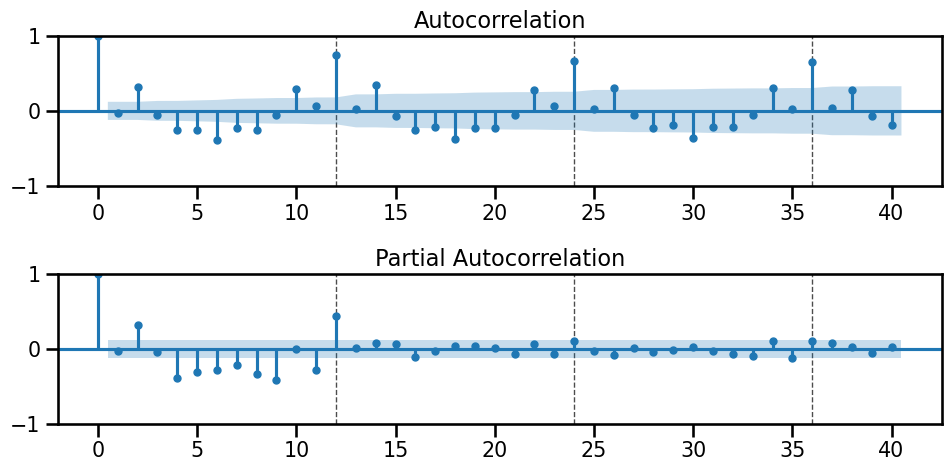

In [ ]:
plot_acf_pacf(ts_battery_diff, annotate_seas=True, m = 12);

## train / test split

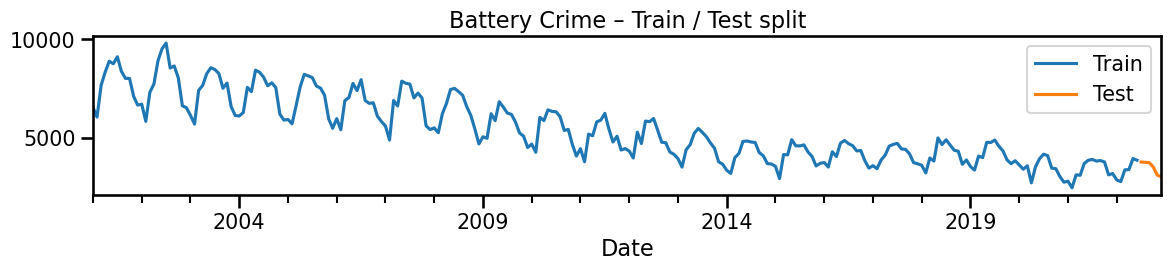

In [ ]:
train_battery, test_battery = train_test_split(ts_battery, test_size=6)
ax = train_battery.plot(label='Train')
test_battery.plot(ax=ax, label='Test')
ax.set_title('Battery Crime – Train / Test split')
ax.legend()
plt.tight_layout()

In [ ]:
p, d, q = 1, 1, 1
P, D, Q, m = 1, 0, 0, 12

sarima_battery = tsa.ARIMA(
    train_battery, order=(p, d, q), seasonal_order=(P, D, Q, m)
).fit()
sarima_battery.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  258
Model:             ARIMA(1, 1, 1)x(1, 0, [], 12)   Log Likelihood               -1860.368
Date:                           Mon, 29 Jun 2026   AIC                           3728.737
Time:                                   12:17:29   BIC                           3742.933
Sample:                               01-31-2001   HQIC                          3734.446
                                    - 06-30-2022                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5296      0.061      8.669      0.000       0.410       0.649
ma.L1         -0.9463      0.022    -42.129      0.000      -0.990      -0.902
ar.S.L12       0.8157      0.028     28.662      0.000       0.760       0.872
sigma2      1.021e+05   9079.818     11.244      0.000    8.43e+04     1.2e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.63   Jarque-Bera (JB):                 0.72
Prob(Q):                              0.43   Prob(JB):                         0.70
Heteroskedasticity (H):               0.40   Skew:                             0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

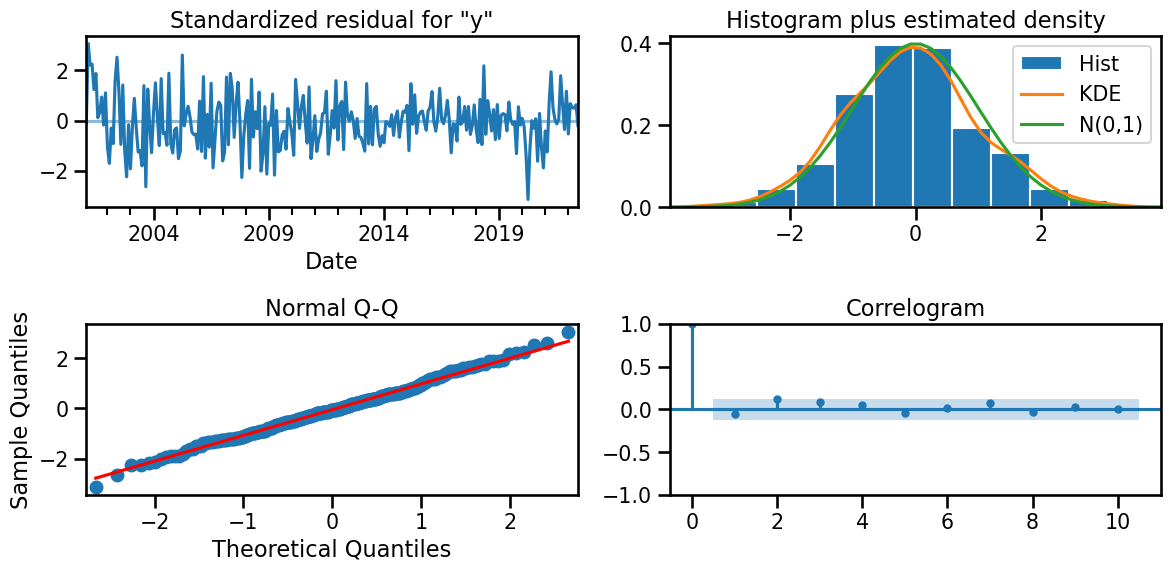

In [ ]:
fig = sarima_battery.plot_diagnostics()
fig.set_size_inches(12, 6)
fig.tight_layout()

--------------------------------------------------
Metrics: Manual Battery – NARCOTICS Crime
--------------------------------------------------
MAE  = 79.452
MSE  = 10,740.816
RMSE = 103.638
R²   = 0.889
MAPE = 2.40%


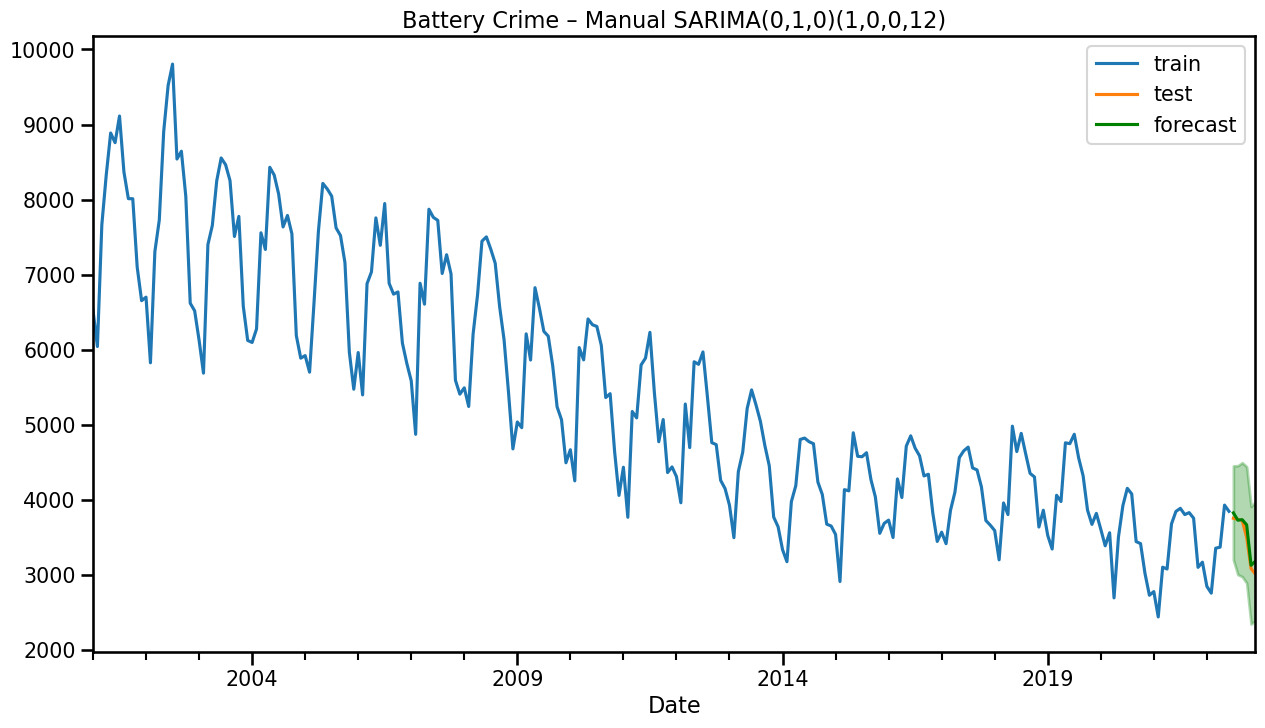

In [ ]:
forecast_manual_battery = sarima_battery.get_forecast(steps=len(test_battery)).summary_frame()
plot_forecast(train_battery, test_battery, forecast_manual_battery,title='Battery Crime – Manual SARIMA(0,1,0)(1,0,0,12)');
metrics_manual_battery = regression_metrics_ts(test_battery, forecast_manual_battery['mean'], label='Manual Battery – NARCOTICS Crime')

In [ ]:
auto_battery = pm.auto_arima(
    train_battery,
    seasonal=True, m=12,
    max_d=1, max_D=1,

    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    information_criterion='aic',
    trace=True,
    stepwise=True
)

print('Best order:', auto_battery.order)
print('Best seasonal order:', auto_battery.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=2.52 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3999.181, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3753.329, Time=0.54 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3872.017, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3997.267, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4000.706, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=1.58 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3680.737, Time=1.12 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3870.170, Time=0.39 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=3.75 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3682.671, Time=2.20 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3836.662, Time=0.97 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.95 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=3704.855, Time=0.98 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : 

--------------------------------------------------
Metrics: auto_arima – Battery Crime
--------------------------------------------------
MAE  = 95.193
MSE  = 17,440.127
RMSE = 132.061
R²   = 0.820
MAPE = 2.61%


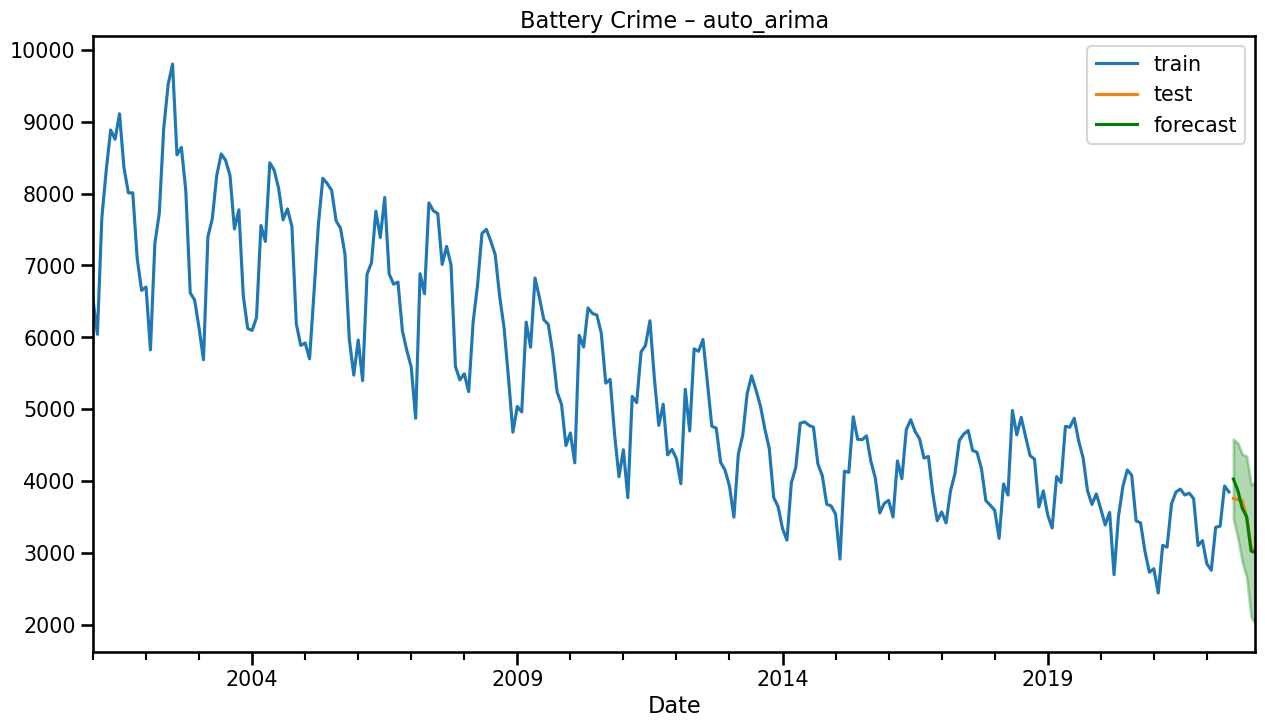

In [ ]:
# Fit statsmodels ARIMA with auto_arima
auto_model_battery = tsa.ARIMA(
    train_battery,
    order=auto_battery.order,
    seasonal_order=auto_battery.seasonal_order
).fit()

forecast_auto_battery = auto_model_battery.get_forecast(steps=len(test_battery)).summary_frame()
plot_forecast(train_battery, test_battery, forecast_auto_battery,title='Battery Crime – auto_arima');
metrics_auto_battery = regression_metrics_ts(test_battery, forecast_auto_battery['mean'], label='auto_arima – Battery Crime')

In [ ]:
print(metrics_manual_battery)
print(metrics_auto_battery)

{'MAE': 79.4523732587176, 'MSE': 10740.815869257758, 'RMSE': 103.63790749169803, 'R2': 0.8890410310120652, 'MAPE': 2.4030826538631285}
{'MAE': 95.19267917555051, 'MSE': 17440.12671185695, 'RMSE': 132.06107190181726, 'R2': 0.8198331949339788, 'MAPE': 2.6089418056928397}


In [ ]:
final_battery = tsa.ARIMA(
    ts_battery,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 12)
).fit()

future_battery = final_battery.get_forecast(steps=6).summary_frame()
print('Forecast dates:')
print(future_battery[['mean', 'mean_ci_lower', 'mean_ci_upper']].round(0))

Forecast dates:
y             mean  mean_ci_lower  mean_ci_upper
2023-01-31  2810.0         2190.0         3430.0
2023-02-28  2771.0         2054.0         3488.0
2023-03-31  3278.0         2527.0         4029.0
2023-04-30  3299.0         2533.0         4065.0
2023-05-31  3762.0         2987.0         4536.0
2023-06-30  3697.0         2917.0         4477.0


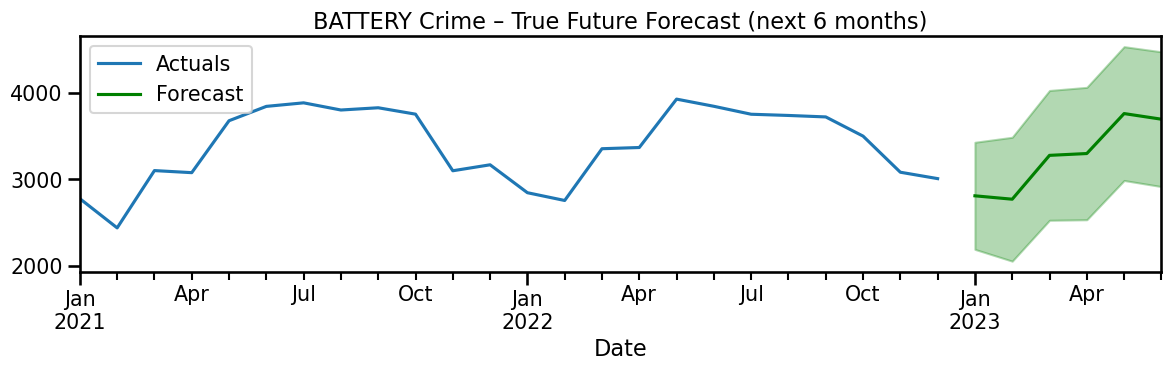

In [ ]:
# Plot: last 24 months of actuals + 6-month future forecast
fig, ax = plt.subplots(figsize=(12, 4))
ts_battery.iloc[-24:].plot(ax=ax, label='Actuals')
future_battery['mean'].plot(ax=ax, color='green', label='Forecast')
ax.fill_between(future_battery.index,
                future_battery['mean_ci_lower'],
                future_battery['mean_ci_upper'],
                color='green', alpha=0.3)
ax.set_title('BATTERY Crime – True Future Forecast (next 6 months)')
ax.legend()
fig.tight_layout()

In [ ]:
start_battery = future_battery['mean'].iloc[0]
end_battery   = future_battery['mean'].iloc[-1]
delta_battery = end_battery - start_battery
pct_battery  = (delta_battery / start_battery) * 100

print(f'Forecast start: {start_battery:,.0f} ')
print(f'Forecast end: {end_battery:,.0f} ')
print(f'Net change: {delta_battery:+,.0f}')
print(f'Percent change: {pct_battery:+.2f}%')

Forecast start: 2,810 
Forecast end: 3,697 
Net change: +887
Percent change: +31.55%


# Final Evaluation

In [ ]:
print("=" * 55)
print("Crime Type Comparison - End of Forecast")
print("=" * 50)

print(f" Assault - End Count: {end_assault:,.0f}")
print(f" Battery  - End Count: {end_battery:,.0f}")
print()
print(f" Assault - Net Change: {delta_assault:+,.0f}")
print(f" Battery - Net Change: {delta_battery:+,.0f}")
print()
print(f" Assault - % Change: {pct_assault:+.2f}%")
print(f" Battery - % Change: {pct_battery:+.2f}%")
print("=" * 50)

if end_assault > end_battery:
    print(f"\nHighest monthly count: Assault")
else:
    print(f"\nHighest monthly count: Battery")

if abs(delta_assault) > abs(delta_battery):
    print(f"Highest net change: Assault")
else:
    print(f"Highest net change: Battery")

if abs(pct_assault) > abs(pct_battery):
    print(f"Highest % change: Assault")
else:
    print(f"Highest % change: Battery")

Crime Type Comparison - End of Forecast
 Assault - End Count: 2,007
 Battery  - End Count: 3,697

 Assault - Net Change: +470
 Battery - Net Change: +887

 Assault - % Change: +30.53%
 Battery - % Change: +31.55%

Highest monthly count: Battery
Highest net change: Battery
Highest % change: Battery


# Final Recommendations

### Overview
Analysis of Chicago crime forecasts for the next 6 months (Jan - Jun 2023) reveals a consistent **seasonal upward trend** in both Battery and Assault crimes, requiring proactive resource allocation.

---

### Forecast Summary

| Crime Type | Jan 2023 | Jun 2023 | % Change |
|------------|----------|----------|----------|
| Battery    | ~2,800   | 3,697    |  +31.55% |
| Assault    | ~1,500   | 2,007    |  +30.53% |

---

### Recommendations

1. **Increase patrols before March 2023** - Crime usually increases before summer.

2. **Focus on Battery Crime** - Expected to hit 3,697 cases by June

3. **Review results every month** - Update plans if actual crime differs from the forecast

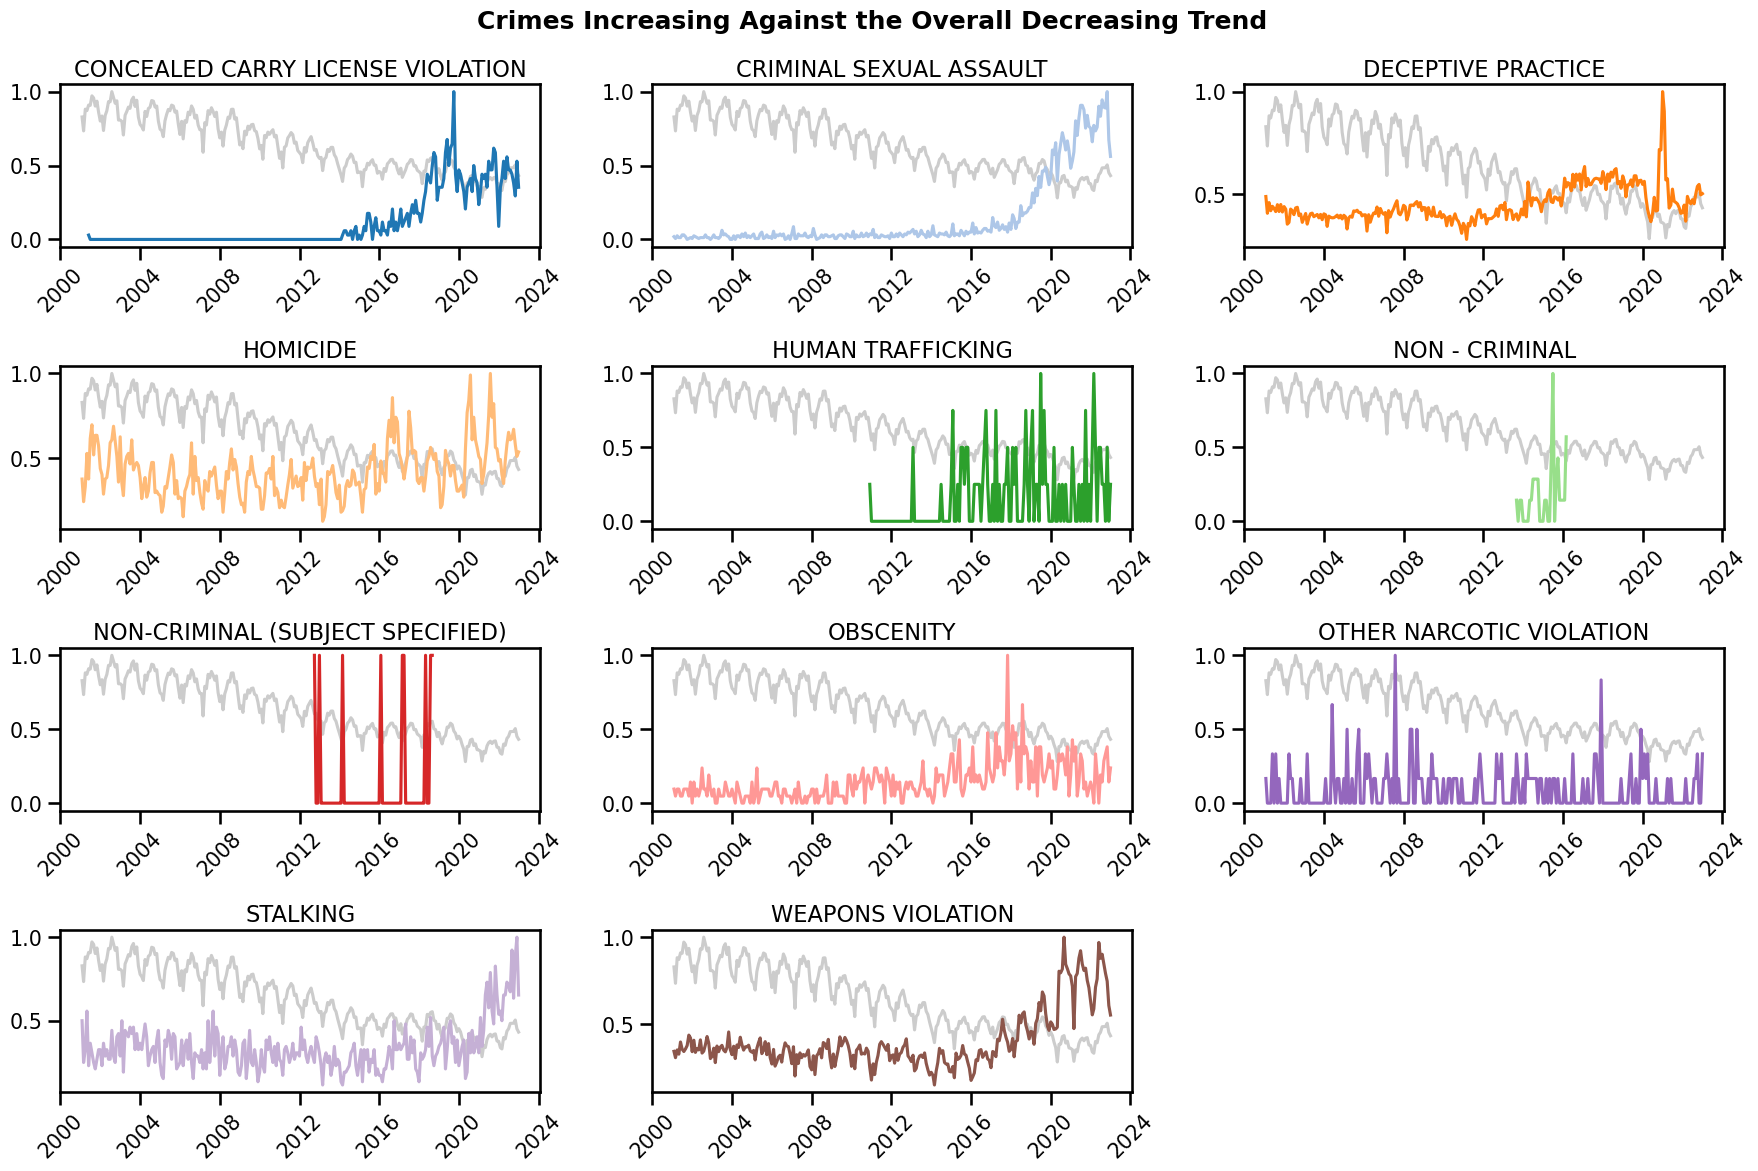

In [ ]:
counter_crimes = [
    'CONCEALED CARRY LICENSE VIOLATION',
    'CRIMINAL SEXUAL ASSAULT',
    'DECEPTIVE PRACTICE',
    'HOMICIDE',
    'HUMAN TRAFFICKING',
    'NON - CRIMINAL',
    'NON-CRIMINAL (SUBJECT SPECIFIED)',
    'OBSCENITY',
    'OTHER NARCOTIC VIOLATION',
    'STALKING',
    'WEAPONS VIOLATION'
]

total_monthly = df.resample('ME').size()
colors = plt.cm.tab20.colors

fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()

for i in range(len(counter_crimes)):

    crime = counter_crimes[i]

    crime_data = df[df['Primary Type'] == crime].resample('ME').size()

    crime_norm = crime_data / crime_data.max()
    total_norm = total_monthly / total_monthly.max()

    axes[i].plot(total_norm.index,total_norm.values,color='gray',alpha=0.4,label='Overall Trend')

    axes[i].plot(crime_norm.index,crime_norm.values,color=colors[i],label=crime)

    axes[i].set_title(crime)
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)

fig.suptitle('Crimes Increasing Against the Overall Decreasing Trend',fontsize=18 , fontweight='bold')

plt.tight_layout()

Although overall crime in Chicago has decreased since 2001, some crimes have continued to rise. **Weapons Violation**, **Criminal Sexual Assault**, and **Stalking** show clear upward trends and may require more focused intervention.